In [18]:
import xarray as xr
import pandas as pd
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.cm import ScalarMappable
from scipy import stats
from scipy.interpolate import griddata
# import xesmf as xe
from pathlib import Path
import cartopy.crs as ccrs
import netCDF4  
import time
# import mpl_toolkits.basemap
# import pyresample 
import utils as u

In [19]:
month_list = ["Jan","Feb","Mar","Apr","May","Jun","Jul","Aug","Sep","Oct","Nov","Dec"]
season_list = ["DJF","MAM","JJA","SON"]

### MAR

In [84]:
# MAR topography
sourceDataGrid='/home/amoryc/'
fileName_grF='NST.2000.01.01.00.GRf.nc'
ds_grF= xr.open_dataset(sourceDataGrid+fileName_grF)

In [85]:
print('Fedchenko domain')
print('lon min',ds_grF.LON.values.min(),'lon max',ds_grF.LON.values.max())
print('lat min',ds_grF.LAT.values.min(),'lat max',ds_grF.LAT.values.max())

latlim_grF=slice(ds_grF.LAT.values.min(),ds_grF.LAT.values.max())
lonlim_grF=slice(ds_grF.LON.values.min(),ds_grF.LON.values.max())

Fedchenko domain
lon min 67.45302 lon max 77.20667
lat min 36.148087 lat max 41.407486


In [82]:
sourceData='/bettik/amoryc/MARout/GRf/spin2/work/'
variable='TT' 

fileNameF='mon-'+variable+'-MARv3.14_ER5-2000-2023.nc'
dsF= xr.open_dataset(sourceData+fileNameF).isel(ATMLAY=1).TT.load()

dsF = dsF.assign_coords(X=np.round(dsF.X.values))
dsF = dsF.assign_coords(Y=np.round(dsF.Y.values))
dsF = dsF.rename({'TIME': 'time'})

dsF = dsF.sel(time=slice("2000-01-01", "2020-12-31"))

model1='MAR'
res1=str('5kmx5km')

### ERA5

In [81]:
folder_era5='/bettik/PROJECTS/pr-regional-climate/observations/ERA5/'
tmp_era5 = xr.open_mfdataset(folder_era5 + 'era5_GRf_t2m.nc').t2m.load()-273.15

tmp_era5=tmp_era5.rename({'latitude':'lat', 'longitude':'lon', 'valid_time':'time'})

tmp_era5 = tmp_era5.sel(time=slice("2000-01-01", "2020-12-31"))

model2='ERA5'
res2=str('31kmx31km')

### ERA5-land

In [79]:
folder_era5land='/bettik/PROJECTS/pr-regional-climate/observations/ERA5-land/'
tmp_era5land = xr.open_mfdataset(folder_era5land + 'era5_land_GRf_t2m.nc').t2m.load()-273.15

tmp_era5land=tmp_era5land.rename({'latitude':'lat', 'longitude':'lon'})
tmp_era5land = tmp_era5land.rename({'valid_time': 'time'})

tmp_era5land = tmp_era5land.sel(time=slice("2000-01-01", "2020-12-31"))

model3='ERA5-Land'
res3=str('0.1°x0.1°')

### CRU

In [47]:
# Could to download latest version of CRU data
# 2021-2023 data missing

folder_cru='/bettik/PROJECTS/pr-regional-climate/santolam/cru/'
tmp_cru = xr.open_mfdataset(folder_cru + 'cru_ts4.05.1901.2020.tmp.dat.nc').sel(lat=latlim_grF,lon=lonlim_grF).tmp.load()
tmp_cru=tmp_cru.sel(time=tmp_cru.time[np.isin(tmp_cru.time.dt.year,[2000, 2020])])

model4='CRU'
res4=str('0.5°x0.5°')

In [57]:
modelList=[model1,model2,model3,model4]
resList=[res1,res2,res3,res4]
print(modelList)
print(resList)

['MAR', 'ERA5', 'ERA5-Land', 'CRU']
['5kmx5km', '0.1°x0.1°', '0.1°x0.1°', '0.5°x0.5°']


In [64]:
dsList=[dsF,tmp_era5, tmp_era5land, tmp_cru]

In [65]:
avgList=[]
for i,elem in enumerate(dsList):
    if i==0:
        print(i)
        print(modelList[i],resList[i])
        avg0=elem.mean(dim='X').mean(dim='Y')
    elif i in [1,2,3]:
        print(i)
        print(modelList[i],resList[i])
        avg0=elem.mean(dim='lon').mean(dim='lat')
    avgList.append(avg0)


0
MAR 5kmx5km
1
ERA5 0.1°x0.1°
2
ERA5-Land 0.1°x0.1°
3
CRU 0.5°x0.5°


In [66]:
annualCycleList = []

for da in avgList:
    # Compute the climatological mean for each month
    clim = da.groupby('time.month').mean('time')
    annualCycleList.append(clim)

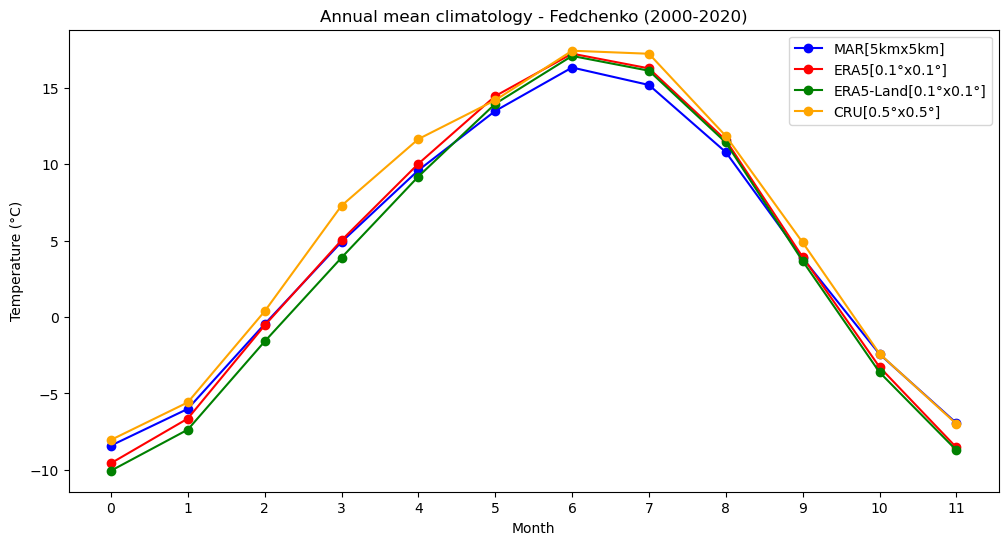

In [83]:
title="Annual mean climatology - Fedchenko (2000-2020)"

xmonths=np.arange(0,12,1)

fig, ax = plt.subplots(figsize=(12, 6))
my_ticks=xmonths

ax.plot(xmonths, annualCycleList[0], 'b',linestyle='-',marker='o',label=modelList[0]+'['+ resList[0]+']')

ax.plot(xmonths, annualCycleList[1], 'r',linestyle='-',marker='o',label=modelList[1]+'['+ resList[1]+']')
ax.plot(xmonths, annualCycleList[2], 'g',linestyle='-',marker='o',label=modelList[2]+'['+ resList[2]+']')
ax.plot(xmonths, annualCycleList[3], 'orange',linestyle='-',marker='o',label=modelList[3]+'['+ resList[3]+']')



ax.set_xlabel('Month')
ax.set_ylabel('Temperature (°C)')
ax.set_title(title)
freq=5
plt.xticks(xmonths,my_ticks,)
plt.legend()
plt.savefig('AnnualClimato_Fed.png',format='png')
plt.show()